In [2]:
import pandas as pd
import numpy as np
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Download required NLTK data (run only once)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to C:\Users\Hardik
[nltk_data]     Arora\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Hardik
[nltk_data]     Arora\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Hardik
[nltk_data]     Arora\AppData\Roaming\nltk_data...


True

In [4]:
# Set plot style
sns.set_style('whitegrid')
%matplotlib inline

In [5]:
# Load the dataset
df = pd.read_csv('../data/raw/training.1600000.processed.noemoticon.csv', 
                 encoding='latin-1', 
                 header=None)

In [8]:
# Add column names
df.columns = ['target', 'ids', 'date', 'flag', 'user', 'text']

# Display basic info
print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Names:\n{df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()


Dataset Shape: (1600000, 6)

Column Names:
['target', 'ids', 'date', 'flag', 'user', 'text']

First 5 rows:


,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [10]:
# Check target distribution
print("Target Value Counts:")
print(df['target'].value_counts())

Target Value Counts:
target
0    800000
4    800000
Name: count, dtype: int64


C:\Users\Hardik Arora\AppData\Local\Temp\ipykernel_15920\3816440740.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='viridis')


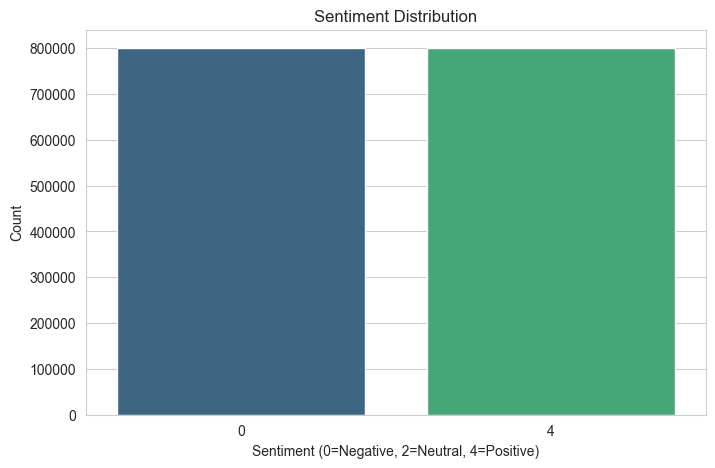

In [11]:
# Visualize target distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='target', data=df, palette='viridis')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment (0=Negative, 2=Neutral, 4=Positive)')
plt.ylabel('Count')
plt.show()

In [12]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
target    0
ids       0
date      0
flag      0
user      0
text      0
dtype: int64


In [13]:
# Check data types
print("\nData Types:")
print(df.dtypes)



Data Types:
target     int64
ids        int64
date      object
flag      object
user      object
text      object
dtype: object


In [14]:
# Check text length statistics
df['text_length'] = df['text'].apply(len)
print(f"\nText Length Stats:\n{df['text_length'].describe()}")


Text Length Stats:
count    1.600000e+06
mean     7.409011e+01
std      3.644114e+01
min      6.000000e+00
25%      4.400000e+01
50%      6.900000e+01
75%      1.040000e+02
max      3.740000e+02
Name: text_length, dtype: float64


In [15]:
# Initialize lemmatizer - converts words to base form (e.g., "running" → "run")
lemmatizer = WordNetLemmatizer()

# Get English stopwords - common words to remove (the, is, at, etc.)
stop_words = set(stopwords.words('english'))

In [16]:
def clean_tweet(text):
    """
    Clean a single tweet by removing unwanted elements
    """
    # Convert to lowercase - ensures uniformity
    text = text.lower()
    # Remove URLs - http:// or https:// links
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove user mentions (@username) and hashtags symbol (#)
    text = re.sub(r'@\w+|#', '', text)
    # Remove punctuation - string.punctuation contains all punctuation chars
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove numbers - \d+ matches any digits
    text = re.sub(r'\d+', '', text)
    # Tokenize - split text into individual words
    tokens = text.split()
    
    # Remove stopwords and lemmatize - keep only meaningful words
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    
    # Join tokens back to string
    cleaned_text = ' '.join(tokens)
    
    return cleaned_text
    

In [17]:
# Apply cleaning function to all tweets
df['cleaned_text'] = df['text'].apply(clean_tweet)

# Display before/after comparison
print("Original Tweet:", df['text'].iloc[0])
print("\nCleaned Tweet:", df['cleaned_text'].iloc[0])

Original Tweet: @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D

Cleaned Tweet: thats bummer shoulda got david carr third day


In [18]:
# Keep only relevant columns - target (sentiment) and cleaned_text
df_clean = df[['target', 'cleaned_text']].copy()


In [19]:
# Remove empty tweets - rows where cleaned_text is empty string
df_clean = df_clean[df_clean['cleaned_text'] != '']

# Remove rows with very short tweets (less than 3 characters) - likely noise
df_clean = df_clean[df_clean['cleaned_text'].str.len() > 3]

# Reset index after filtering - makes index continuous again
df_clean = df_clean.reset_index(drop=True)


In [23]:
# Display cleaned dataset info
print(f"Original dataset size: {len(df)}")
print(f"Cleaned dataset size: {len(df_clean)}")
print(f"Rows removed: {len(df) - len(df_clean)}")
print(f"\nCleaned Data Shape: {df_clean.shape}")
print(f"\nSample Cleaned Data:")
df_clean.head(10)

Original dataset size: 1600000
Cleaned dataset size: 1585888
Rows removed: 14112

Cleaned Data Shape: (1585888, 2)

Sample Cleaned Data:


,target,cleaned_text
0,0,thats bummer shoulda got david carr third day
1,0,upset cant update facebook texting might cry r...
2,0,dived many time ball managed save rest go bound
3,0,whole body feel itchy like fire
4,0,behaving im mad cant see
5,0,whole crew
6,0,need hug
7,0,hey long time see yes rain bit bit lol im fine...
8,0,nope didnt
9,0,que muera


In [26]:


# Save cleaned dataset to processed folder
df_clean.to_csv('../data/processed/cleaned_tweets.csv', 
                index=False,           # Don't save index column
                encoding='utf-8')      # Use UTF-8 encoding

In [27]:
print("✓ Cleaned data saved to: ../data/processed/cleaned_tweets.csv")

# Also save a sample for quick testing (first 10000 rows)
df_sample = df_clean.head(10000)
df_sample.to_csv('../data/processed/cleaned_tweets_sample.csv', 
                 index=False, 
                 encoding='utf-8')

print("✓ Sample data (10K rows) saved to: ../data/processed/cleaned_tweets_sample.csv")

✓ Cleaned data saved to: ../data/processed/cleaned_tweets.csv
✓ Sample data (10K rows) saved to: ../data/processed/cleaned_tweets_sample.csv


Text(0, 0.5, 'Frequency')

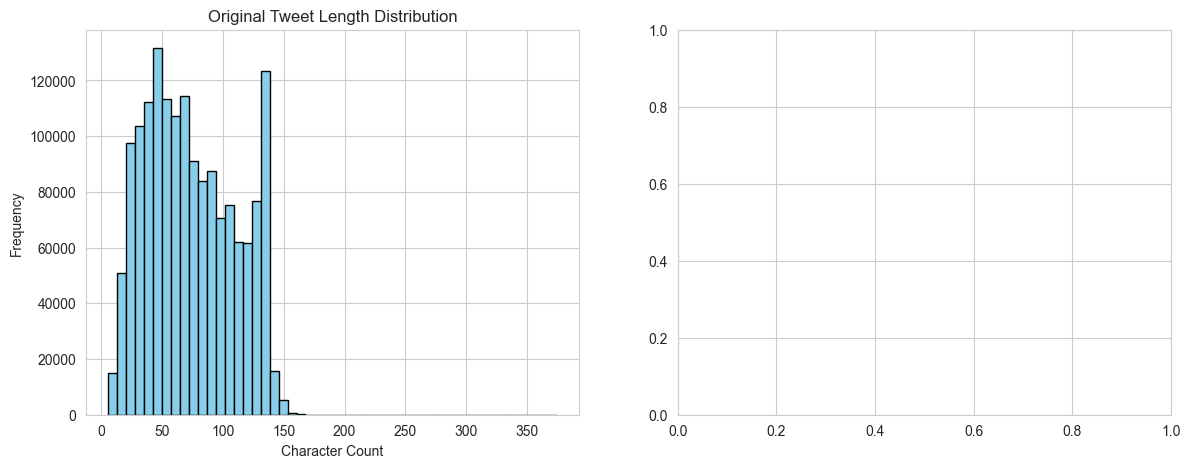

In [28]:
# Visualize text length distribution before and after cleaning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original text length
axes[0].hist(df['text'].apply(len), bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Original Tweet Length Distribution')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')


In [29]:
# Cleaned text length
axes[1].hist(df_clean['cleaned_text'].apply(len), bins=50, color='lightgreen', edgecolor='black')
axes[1].set_title('Cleaned Tweet Length Distribution')
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [30]:
# Print final summary
print("=" * 50)
print("DATA CLEANING SUMMARY")
print("=" * 50)
print(f"Original Dataset: {len(df)} tweets")
print(f"Cleaned Dataset: {len(df_clean)} tweets")
print(f"Data Removed: {len(df) - len(df_clean)} tweets ({((len(df) - len(df_clean)) / len(df) * 100):.2f}%)")
print(f"\nSentiment Distribution:")
print(df_clean['target'].value_counts())
print(f"\nAverage Tweet Length (Original): {df['text'].apply(len).mean():.2f} characters")


DATA CLEANING SUMMARY
Original Dataset: 1600000 tweets
Cleaned Dataset: 1585888 tweets
Data Removed: 14112 tweets (0.88%)

Sentiment Distribution:
target
0    793591
4    792297
Name: count, dtype: int64

Average Tweet Length (Original): 74.09 characters


In [31]:
print(f"Average Tweet Length (Cleaned): {df_clean['cleaned_text'].apply(len).mean():.2f} characters")
print("=" * 50)

Average Tweet Length (Cleaned): 42.82 characters
